<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Data files must have been modified by Calc_dLij_vKonstanz_v1p8.ipynb, also v1p9. Compatible with fit_PSWS_class.py (currently only More-general-plotting branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V 4.2
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
We cleanned unecessary parts

In [2]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt 

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_PSWS
import fit_PSWS_class as fits
import fitting_functions as funcs

import ipywidgets as widgets
from ipywidgets import interact

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [4]:
#Folders where file are. Keep the r to use raw string in Windows.
#address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\DataYIG\PSWS_Konstanz\Antennas_Pt_Au_YIG100nm_3\AMV84_26\2025-11-17_sws")
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\DataYIG\PSWS_Konstanz\Antennas_Pt_Au_YIG100nm_3\ACV84_23\2025-11-24_sws")
#address2 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\DataYIG\PSWS_Konstanz\Antennas_Pt_Au_YIG100nm_3\PMV84_16\2025-11-18&19_sws")
address2 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\DataYIG\PSWS_Konstanz\Antennas_Pt_Au_YIG100nm_3\PCV84_13\2025-11-19_sws")

In [5]:
#file_name_1 = "2025-11-17_otsws_-4Ato4Ain81_0p1to6p01GHz_-30dBm_wCal_22-08.h5.ma8"
file_name_1 = "2025-11-24_otsws_-4Ato4Ain21_0p1to6p01GHz_-30dBm_wCal_17-48.h5.ma8"
#file_name_2 = "2025-11-18_otsws_-4Ato4Ain81_0p1to6p01GHz_-30dBm_wCal_21-31.h5.ma8"
file_name_2 = "2025-11-19_otsws_-4Ato4Ain81_0p1to6p01GHz_-30dBm_wCal_10-07.h5.ma8"

In [6]:
sample = "Antennas_Pt_Au_YIG100nm_3"

In [7]:
device1 = "ACV84_23"
device2 = "PCV84_13"

In [8]:
D_1 = 4 #um Distance between antennas device1
D_2 = D_1 #um Distance between antennas device2

In [9]:
ansy1 = Analysis_PSWS(address1, file_name_1, sample, "Konstanz_PSWS", device1, "inP")
ansy2 = Analysis_PSWS(address2, file_name_2, sample, "Konstanz_PSWS", device2, "inP")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best parameters for the fit.

In [11]:
ansy1.plot_dij_slider('dL', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=20, readout_format='.0f'), Output()), …

In [12]:
#ansy1.plot_dij_slider('dZ', n_0=20)

In [13]:
ansy2.plot_dij_slider('dL', n_0=20)

interactive(children=(IntSlider(value=20, description='Field index', max=80, readout_format='.0f'), Output()),…

{'A': np.float64(34.80176608008699), 'w': np.float64(0.17797837678969997), 'fres': np.float64(4.03941865611341), 'fper': np.float64(0.10172990029245449), 'phi': np.float64(0.0062979699306687995), 're0': np.float64(-0.006225555549473233), 'im0': np.float64(0.023991307897244574)}


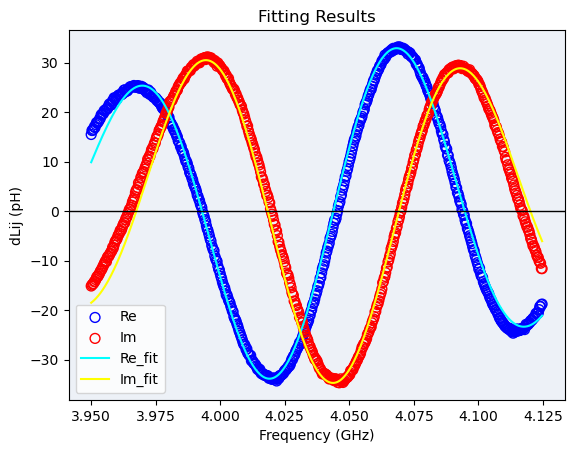

In [14]:
ini_vals = [100, 0.18, 4.05, 0.102, 4.03, 0, 0] #A, w, fres, fper, fref, re0, im0
H_index = 5

f_min, f_max = 3.95, 4.125 #GHz
f_array = ansy1.freqs
y_array_re, y_array_im = ansy1.dL("21R")[H_index], ansy1.dL("21I")[H_index]

model = fits.ComplexGaussianSimple()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re, y_array_im, model)
fitter.fix() #fper=0.12, fres=4.02, Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
fitter.plot_fit_simplex_wpm()

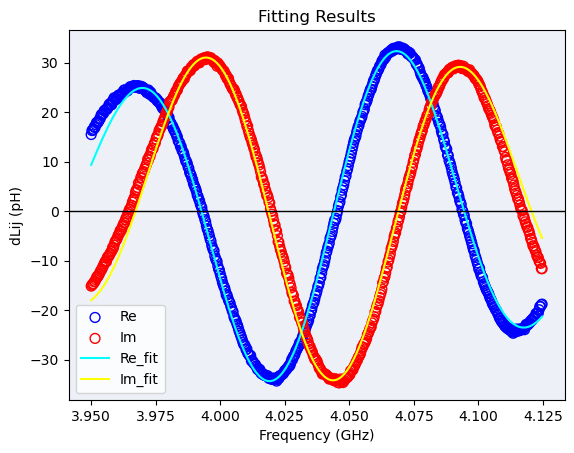


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
A                        34.7733         0.1401    pH/GHz        No
w                         0.1766         0.0020       GHz        No
fres                      4.0388      5.197e-04       GHz        No
fper                      0.1017      1.098e-04       GHz        No
phi                    2.668e-12         0.2692       rad        No
re0                      -0.4659         0.0896        pH        No
im0                       0.5299         0.0915        pH        No
----------------------------------------------------------------------


In [15]:
new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
fitter.plot_fit()
fitter.summary()

In [16]:
D = D_1
print(f"T1= {1/params['fper']:.1f} ns, eff_vg= {D*(params['fper']*1000):.1f} m/s")

T1= 9.8 ns, eff_vg= 406.9 m/s


In [17]:
print(f"Eff. D= {fitter.vg(params['fres']*1e9)*1e9/params['fper']*1e6:.2f} um") #um

Eff. D= 5.59 um


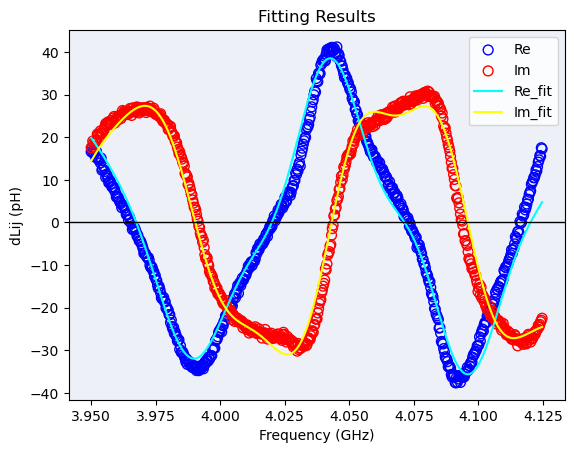

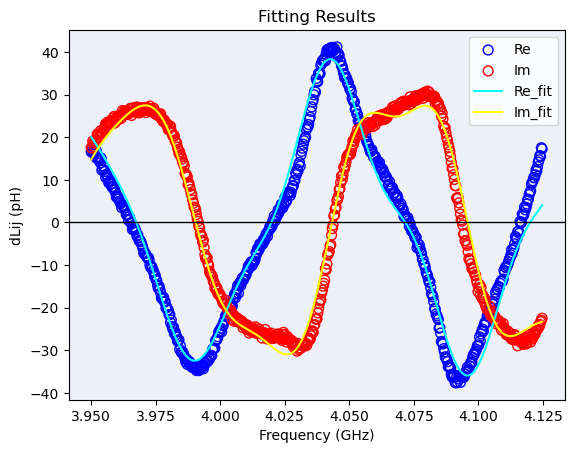


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
A1                       32.1590         0.1938    pH/GHz        No
w1                        0.2963         0.0136       GHz        No
fres1                     4.0457         0.0021       GHz        No
fper1                     0.1041              -       GHz       Yes
phi1                      5.3904         0.0042       rad        No
A2                        6.3453         0.1981    pH/GHz        No
w2                        0.1474         0.0117       GHz        No
fres2                     4.0700         0.0047       GHz        No
fper2                     0.0364      1.385e-04       GHz        No
phi2                      6.2832         2.6615       rad        No
re0                       0.4163         0.1300        pH        No
im0                      -0.4

In [18]:
#initial parameters
ini_vals_1 = [131.9209, 0.1101, 4.0336, 0.105, 4.1086,
                94.1063, 0.05, 4.0819, 0.0367, 3.9850, 0, 0] 

#A1, w1, fres1, fper1, phi1,
#A2, w2, fres2, fper2, phi2, re0, im0

#Selec appropiate data to fit
H_index_1 = 20 #index field to fit 
f_min_1, f_max_1 = 3.95, 4.125  #GHz
f_array_1 = ansy2.freqs #Select the frequency array
y_array_re_1, y_array_im_1 = ansy2.dL("21R")[H_index_1], ansy2.dL("21I")[H_index_1] #Select the Re & Im

#Defining fitting object
model_1 = fits.TwoComplexGaussianSimple()
fitter_1 = fits.ComplexFitter(ini_vals_1, f_min_1, f_max_1,
    f_array_1, y_array_re_1, y_array_im_1, model_1)
fitter_1.fix( fres1= 4.05, fres2=4.06, fper1= 0.1040698319793, fper2=0.0367)#fres1= 4.0336, fres2=4.08, fper1= 0.0737,  fper2=0.0367) # fper1= 0.0737,  fper2=0.0367,
               #)#A1=180, A2=180/4, re0=0,im0=0, fper1=0.0669, fper2=0.0669) #Parameters to be fixed, empty otherwise

#Simplex
opt_p0_1 = fitter_1.simplex_wpm(method='Powell')
new_p0_1 = np.array(list(opt_p0_1.values()), dtype=float)

#New optimized initial param
fitter_1.update_p0(new_p0_1, fper1= 0.1040698319793)#, re0=0,im0=0, fper1=0.0669, fper2=0.0669)
#print(opt_p0_0)
fitter_1.plot_fit_simplex_wpm()

#Actual fit
params_1, cov_1 = fitter_1.fit(simplex_b=False)
fitter_1.plot_fit()
fitter_1.summary()

In [19]:
print(f"The period ratio. is: { float(params_1['fper1']/params_1['fper2'] if params_1['fper1']>params_1['fper2'] else params_1['fper2']/params_1['fper1'])}")

The period ratio. is: 2.8581982114449076


In [20]:
print(f"The phase diff. is: ({float((params_1['phi1']-params_1['phi2']))/(3*np.pi/4):.1f})3pi/4")

The phase diff. is: (-0.4)3pi/4


In [21]:
D = D_1
print(f"T1= {1/params_1['fper1']:.1f} ns, T2= {1/params_1['fper2']:.1f} ns, eff_vg1= {D*(params_1['fper1']*1000):.1f} m/s, eff_vg2= {D*(params_1['fper2']*1000):.1f} m/s")

T1= 9.6 ns, T2= 27.5 ns, eff_vg1= 416.3 m/s, eff_vg2= 145.6 m/s


In [22]:
print(f"Eff. D1= {fitter_1.vg(params_1['fres1']*1e9)*1e9/params_1['fper1']*1e6:.2f} um, Eff. D2={fitter_1.vg(params_1['fres2']*1e9)*1e9/params_1['fper2']*1e6:.2f} um") #um

Eff. D1= 5.46 um, Eff. D2=15.50 um


In [23]:
max_variation = 1 # *100%
step = 0.01/10
mod_params_1 = fitter_1.manipulator_fit(max_variation, step)

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='F*A1, F=', max=2.0, readout…

In [24]:
print(mod_params_1)

{'A1': np.float64(32.15895251992191), 'w1': np.float64(0.29633411802119336), 'fres1': np.float64(4.045715740085345), 'fper1': 0.1040698319793, 'phi1': np.float64(5.390362377036993), 'A2': np.float64(6.345328243759495), 'w2': np.float64(0.14744874173427086), 'fres2': np.float64(4.069973320547362), 'fper2': np.float64(0.036410991918817796), 'phi2': np.float64(6.283185307162615), 're0': np.float64(0.4162604786977614), 'im0': np.float64(-0.48634440742455104)}


In [ ]:
small_comp = fits.ComplexGaussianSimple()
large_comp_re, large_comp_im = funcs.unconcatenate( small_comp.model(f_array_1, mod_params_1["A1"],mod_params_1["w1"],mod_params_1["fres1"],
                                   mod_params_1["fper1"], mod_params_1["phi2"], 0,0)
                                                  )
small_comp_re, small_comp_im = funcs.unconcatenate( small_comp.model(f_array_1, mod_params_1["A2"],mod_params_1["w2"],mod_params_1["fres2"],
                                   mod_params_1["fper2"], mod_params_1["phi2"], 0,0) 
                                                 )#mod_params_1["re0"], mod_params_1["im0"]
subs_re = y_array_re_1 - small_comp_re
subs_im = y_array_im_1 - small_comp_im
subs_m = np.sqrt(subs_re*subs_re+subs_im*subs_im)
y_array_m = np.sqrt(y_array_re_1*y_array_re_1+y_array_im_1*y_array_im_1)
Au_m = np.sqrt(y_array_re*y_array_re+y_array_im*y_array_im)

#plt.scatter(f_array_1, y_array_re_1, s=50, facecolors='none', edgecolors='blue', label="Re")
#plt.scatter(f_array_1, y_array_im_1, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, subs_re, s=50, facecolors='none', edgecolors='blue', label="Re")
plt.scatter(f_array_1, subs_im, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, y_array_m, s=50, facecolors='none', edgecolors='pink', label="Pt_Total")
plt.scatter(f_array_1, Au_m, s=50, facecolors='none', edgecolors='orange', label="Au_Total")
plt.scatter(f_array_1, subs_m, s=10, facecolors='none', edgecolors='purple', label="Sub")
plt.plot(f_array_1, small_comp_re, 'cyan', label="Re_fit")
plt.plot(f_array_1, small_comp_im, 'yellow', label="Im_fit")

plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.75, 4.25)     # x-axis range
#plt.ylim(-0.5, 0.5)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
#initial parameters
ini_vals_2 = [131.9209, 0.11, 4.0336, 0.105, 4.1086,
                94.1063, 0.03, 4.0819, 0.0367, 3.9850, 0, 0] 

#A1, w1, fres1, fper1, phi1,
#A2, w2, fres2, fper2, phi2, re0, im0

#Selec appropiate data to fit
H_index_1 = 20 #index field to fit 
f_min_2, f_max_2 = 3.975, 4.17  #GHz
f_array_2 = ansy2.freqs #Select the frequency array
y_array_re_2, y_array_im_2 = ansy2.dL("12R")[H_index_1], ansy2.dL("12I")[H_index_1] #Select the Re & Im

#Defining fitting object
model_2 = fits.TwoComplexGaussianSimple()
fitter_2 = fits.ComplexFitter(ini_vals_2, f_min_2, f_max_2,
    f_array_2, y_array_re_2, y_array_im_2, model_2)
fitter_2.fix(fres1= 4.08, fres2= 4.1,  fper1= 0.1030698319793, fper2=0.0367, w1=0.06, w2=0.03)#fres1= 4.0336, fres2=4.08, fper1= 0.0737,  fper2=0.0367) # fper1= 0.0737,  fper2=0.0367,
               #)#A1=180, A2=180/4, re0=0,im0=0, fper1=0.0669, fper2=0.0669) #Parameters to be fixed, empty otherwise

#Simplex
opt_p0_2 = fitter_2.simplex_wpm(method='Powell')
new_p0_2 = np.array(list(opt_p0_2.values()), dtype=float)

#New optimized initial param
fitter_2.update_p0(new_p0_2, fres1= 4.08, fres2= 4.1,  fper1= 0.1030698319793, fper2=0.0367, w1=0.06, w2=0.03)#, re0=0,im0=0, fper1=0.0669, fper2=0.0669)
#print(opt_p0_0)
fitter_2.plot_fit_simplex_wpm()

#Actual fit
params_2, cov_2 = fitter_2.fit(simplex_b=False)
fitter_2.plot_fit()
fitter_2.summary()

In [ ]:
max_variation = 1 # *100%
step = 0.01/10
mod_params_2 = fitter_2.manipulator_fit(max_variation, step)

In [ ]:
small_comp_12 = fits.ComplexGaussianSimple()
large_comp_re_12, large_comp_im_12 = funcs.unconcatenate( small_comp.model(f_array_2, mod_params_2["A1"],mod_params_2["w1"],mod_params_2["fres1"],
                                   mod_params_2["fper1"], mod_params_2["phi2"], 0,0)
                                                        )
small_comp_re_12, small_comp_im_12 = funcs.unconcatenate( small_comp.model(f_array_2, mod_params_2["A2"],mod_params_2["w2"],mod_params_2["fres2"],
                                   mod_params_2["fper2"], mod_params_2["phi2"], mod_params_2["re0"], mod_params_2["im0"]) 
                                                 )#mod_params_1["re0"], mod_params_1["im0"]
subs_re_12 = y_array_re_2 - small_comp_re_12
subs_im_12 = y_array_im_2 - small_comp_im_12
subs_m_12 = np.sqrt(subs_re_12*subs_re_12+subs_im_12*subs_im_12)
y_array_m_12 = np.sqrt(y_array_re_2*y_array_re_2+y_array_im_2*y_array_im_2)
Au_m_12 = np.sqrt(ansy1.dL("12R")[H_index_1]*ansy1.dL("12R")[H_index_1]+ansy1.dL("12I")[H_index_1]*ansy1.dL("12I")[H_index_1])

#plt.scatter(f_array_1, y_array_re_1, s=50, facecolors='none', edgecolors='blue', label="Re")
#plt.scatter(f_array_1, y_array_im_1, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, subs_re_12, s=50, facecolors='none', edgecolors='blue', label="Re")
plt.scatter(f_array_1, subs_im_12, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, y_array_m_12, s=50, facecolors='none', edgecolors='pink', label="Pt_Total")
plt.scatter(f_array_1, Au_m_12, s=50, facecolors='none', edgecolors='orange', label="Au_Total")
plt.scatter(f_array_1, subs_m_12, s=10, facecolors='none', edgecolors='purple', label="Sub")
plt.plot(f_array_1, small_comp_re_12, 'cyan', label="Re_fit")
plt.plot(f_array_1, small_comp_im_12, 'yellow', label="Im_fit")

plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.9, 4.25)     # x-axis range
plt.ylim(-10, 10)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
plt.scatter(f_array_1, subs_m, s=40, facecolors='none', edgecolors='purple', label="k>0")
plt.scatter(f_array_1, subs_m_12, s=40, facecolors='none', edgecolors='orange', label="k<0")


plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.8, 4.25)     # x-axis range
plt.ylim(0, 60)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
plt.scatter(f_array_1, y_array_m, s=40, facecolors='none', edgecolors='purple', label="k>0")
plt.scatter(f_array_1, y_array_m_12, s=40, facecolors='none', edgecolors='orange', label="k<0")


plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.8, 4.25)     # x-axis range
plt.ylim(0, 60)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
large_comp_m = np.sqrt(large_comp_re*large_comp_re+large_comp_im*large_comp_im)
large_comp_m_12 = np.sqrt(large_comp_re_12*large_comp_re_12+large_comp_im_12*large_comp_im_12)
plt.scatter(f_array_1, large_comp_m, s=40, facecolors='none', edgecolors='purple', label="k>0")
plt.scatter(f_array_1, large_comp_m_12, s=40, facecolors='none', edgecolors='orange', label="k<0")


plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.7, 4.3)     # x-axis range
plt.ylim(0, 60)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
#initial parameters
ini_vals_3 = [131.9209, 0.1101, 4.0457, 0.105, 4.1086,
                94.1063, 0.05, 4.07, 0.0367, 3.9850,
              5.3, 0.05, 4.085, 0.0367, 3.9850, 0, 0] 

#A1, w1, fres1, fper1, phi1,
#A2, w2, fres2, fper2, phi2, re0, im0

#Selec appropiate data to fit
H_index_3 = 20 #index field to fit 
f_min_3, f_max_3 = 3.85, 4.23  #GHz
f_array_3 = ansy2.freqs #Select the frequency array
y_array_re_3, y_array_im_3 = ansy2.dL("21R")[H_index_1], ansy2.dL("21I")[H_index_1] #Select the Re & Im

#Defining fitting object
model_3 = fits.ThreeComplexGaussianSimple()
fitter_3 = fits.ComplexFitter(ini_vals_3, f_min_3, f_max_3,
    f_array_3, y_array_re_3, y_array_im_3, model_3)
fitter_3.fix(fres1= 4.0457, fres2=4.07,   fper1= 0.104, fper2=0.0364, fper3=0.0364)#fres1= 4.0336, fres2=4.08, fper1= 0.0737,  fper2=0.0367) # fper1= 0.0737,  fper2=0.0367,
               #)#A1=180, A2=180/4, re0=0,im0=0, fper1=0.0669, fper2=0.0669) #Parameters to be fixed, empty otherwise

#Simplex
opt_p0_3 = fitter_3.simplex_wpm(method='Powell')
new_p0_3 = np.array(list(opt_p0_3.values()), dtype=float)

#New optimized initial param
fitter_3.update_p0(new_p0_3, fres1= 4.0457, fres2=4.07,  fres3=4.085, fper1= 0.104, fper2=0.0364, fper3=0.0364)#, re0=0,im0=0, fper1=0.0669, fper2=0.0669)
#print(opt_p0_0)
fitter_3.plot_fit_simplex_wpm()

#Actual fit
params_3, cov_3 = fitter_3.fit(simplex_b=False)
fitter_3.plot_fit()
fitter_3.summary()

In [ ]:
max_variation = 1 # *100%
step = 0.01/10
mod_params_3 = fitter_3.manipulator_fit(max_variation, step)

In [ ]:
small_comp = fits.ComplexGaussianSimple()
large_comp_re, large_comp_im = funcs.unconcatenate( small_comp.model(f_array_3, mod_params_3["A1"],mod_params_3["w1"],mod_params_3["fres1"],
                                   mod_params_3["fper1"], mod_params_3["phi2"], 0,0)
                                                  )
small_comp_re_a, small_comp_im_a = funcs.unconcatenate( small_comp.model(f_array_3, mod_params_3["A2"],mod_params_3["w2"],mod_params_3["fres2"],
                                   mod_params_3["fper2"], mod_params_3["phi2"], 0,0) 
                                                 )
small_comp_re_b, small_comp_im_b = funcs.unconcatenate( small_comp.model(f_array_3, mod_params_3["A3"],mod_params_3["w3"],mod_params_3["fres3"],
                                   mod_params_3["fper3"], mod_params_3["phi3"],0,0) 
                                                 )#, mod_params_3["re0"], mod_params_3["im0"]

subs_re = y_array_re_3 - small_comp_re_a - small_comp_re_b
subs_im = y_array_im_3 - small_comp_im_a - small_comp_im_b

subs_m = np.sqrt(subs_re*subs_re+subs_im*subs_im)
y_array_m = np.sqrt(y_array_re_3*y_array_re_3+y_array_im_3*y_array_im_3)
Au_m = np.sqrt(y_array_re*y_array_re+y_array_im*y_array_im)

#plt.scatter(f_array_1, y_array_re_1, s=50, facecolors='none', edgecolors='blue', label="Re")
#plt.scatter(f_array_1, y_array_im_1, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, subs_re, s=50, facecolors='none', edgecolors='blue', label="Re")
plt.scatter(f_array_1, subs_im, s=50, facecolors='none', edgecolors='red', label="Im")
plt.scatter(f_array_1, y_array_m, s=50, facecolors='none', edgecolors='pink', label="Pt_Total")
plt.scatter(f_array_1, Au_m, s=50, facecolors='none', edgecolors='orange', label="Au_Total")
plt.scatter(f_array_1, subs_m, s=10, facecolors='none', edgecolors='purple', label="Sub")
plt.plot(f_array_1, small_comp_re, 'cyan', label="Re_fit")
plt.plot(f_array_1, small_comp_im, 'yellow', label="Im_fit")

plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.75, 4.25)     # x-axis range
#plt.ylim(-0.5, 0.5)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
plt.scatter(f_array_1, subs_m, s=40, facecolors='none', edgecolors='purple', label="k>0")
plt.scatter(f_array_1, subs_m_12, s=40, facecolors='none', edgecolors='orange', label="k<0")


plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.8, 4.25)     # x-axis range
plt.ylim(0, 60)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()

In [ ]:
plt.scatter(f_array_1, Au_m, s=40, facecolors='none', edgecolors='purple', label="k>0")
plt.scatter(f_array_1, Au_m_12, s=40, facecolors='none', edgecolors='orange', label="k<0")


plt.axhline(0, color='black', linewidth=1)
plt.gca().set_facecolor('#edf1f7')
plt.xlim(3.8, 4.25)     # x-axis range
plt.ylim(0, 60)  # y-axis range
plt.xlabel("Frequency (GHz)")
plt.ylabel("dLij (pH)")
plt.title("Fitting Results")

plt.legend()
plt.show()